Classification neural network

1. Make Classification Data

In [1]:
#making classification data ready
from sklearn.datasets import make_circles

#Make 1000 samples
n_samples = 1000

#create circles
X, y = make_circles(n_samples, noise = 0.03, random_state =30) #noise =0 perfect circles, else points will scattered around the circle based on the noise value
#returns X -> NumPy array, feature matrix(data points) shape(n_samples, 2), contains (x,y) coordinates of each point
# and y NumPy array, target labels shape(n_samples,) class label 0 or 1. 0 inner circle, 1 outer circle

In [2]:
print(f" First X features:\n{X[:5]}")
print(f" First y labels:\n{y[:5]}")

 First X features:
[[ 0.47975597 -0.70363449]
 [ 0.48782766 -0.65129039]
 [ 0.74450673  0.1202565 ]
 [ 0.43280373  0.92825379]
 [ 0.07717132 -0.8001889 ]]
 First y labels:
[1 1 1 0 1]


In [3]:
X.shape, y.shape

((1000, 2), (1000,))

In [4]:
type(X) , type(y)

(numpy.ndarray, numpy.ndarray)

In [5]:
#Making dataframe of circle data using pandas lib
import pandas as pd
circles = pd.DataFrame({"X1" : X[:,0],
                       "X2" : X[:,1],
                       "label" : y})
circles.head(10)


,X1,X2,label
0,0.479756,-0.703634,1
1,0.487828,-0.651290,1
2,0.744507,0.120257,1
3,0.432804,0.928254,0
4,0.077171,-0.800189,1
5,0.923498,-0.465596,0
6,0.192272,0.995803,0
7,-0.784262,-0.548423,0
8,0.480338,-0.872635,0
9,-0.374468,0.748411,1


In [6]:
#check different lables 
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

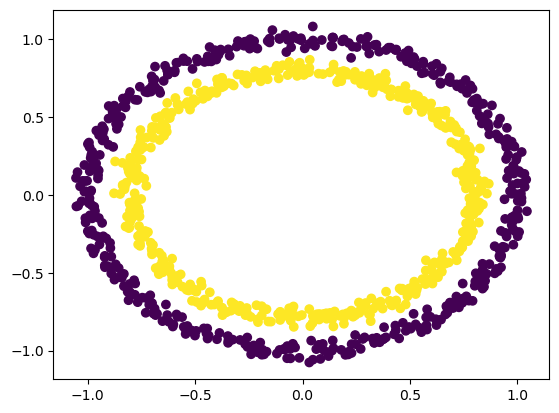

In [7]:
#vizualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:,1],c=y)
            

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
type(X) , type(y)

(numpy.ndarray, numpy.ndarray)

In [10]:
#turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.4798, -0.7036],
         [ 0.4878, -0.6513],
         [ 0.7445,  0.1203],
         [ 0.4328,  0.9283],
         [ 0.0772, -0.8002]]),
 tensor([1., 1., 1., 0., 1.]))

In [11]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [12]:
#Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

print(len(X_train), len(X_test), len(y_train), len(y_test))

800 200 800 200


In [13]:
X_train.shape, X_test.shape, y_train.shape , y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

2. Building a model


In [14]:
#Creating a model class that subclasses the nn.Module
import torch
from torch import nn
class CircleModel(nn.Module):
    def __init__(self):
       super().__init__()
       self.layer_1 = nn.Linear(in_features = 2, out_features = 10) # takes in 2 features (X) , produces 10 features
       self.layer_2 = nn.Linear(in_features = 10, out_features = 10) # takes in 10 features, produce 10 feacture 
       self.layer_3 = nn.Linear(in_features =10 ,out_features = 1) # takes 10 in and gives 1 feacture (y)
       self.relu = nn.ReLU() ## adding ReLU activation fucntion
        
    def forward(self, x):
        #return output of layer 3, a single feature, the same shape as y  #  Linear -> ReLU -> Linear -> ReLU -> Linear 
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))     # Intersperse the ReLU activation function between layers

#create instance of model
model_0 = CircleModel()

In [15]:
model_0

CircleModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [16]:
for name, param in model_0.named_parameters():
    print(name, param.shape)

layer_1.weight torch.Size([10, 2])
layer_1.bias torch.Size([10])
layer_2.weight torch.Size([10, 10])
layer_2.bias torch.Size([10])
layer_3.weight torch.Size([1, 10])
layer_3.bias torch.Size([1])


In [17]:
total_params = sum(p.numel() for p in model_0.parameters())
print(total_params)

151


In [18]:
#Another way of creating the model in pytorch is using nn.sequential. here Automatically defines forward pass
#if model is simple use nn.Sequential, for full custom model or complex model then create model Class
# model_0 = nn.Sequential(
#     nn.Linear(in_features = 2, out_features = 5),
#     nn.Linear(in_features = 5, out_features = 1)
# )
# model_0

In [19]:
untrained_preds = model_0(X_test) # model output is logits
print(f"shape of untrained pred \n {untrained_preds.shape}") # the output shape of model is torch.Size([200, 1]) so we use squeeze in the training to remove the dimension of size 1
print(f"length of predictions: \n {len(untrained_preds)}")
print(f"length and shape of test samples: \n { len(y_test), y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10].squeeze()}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")


shape of untrained pred 
 torch.Size([200, 1])
length of predictions: 
 200
length and shape of test samples: 
 (200, torch.Size([200]))

First 10 predictions:
tensor([-0.0760, -0.0622, -0.0522, -0.0968, -0.0525, -0.0739, -0.1157, -0.0765,
        -0.0961, -0.1521], grad_fn=<SqueezeBackward0>)

First 10 test labels:
tensor([1., 1., 0., 1., 0., 1., 0., 0., 1., 0.])


In [20]:
#calculate accuracy
def accuracy_fn(y_true, y_pred): ## Compares y_true and y_pred element-wise, converts True to 1 and False to 0, 
    # sums them to count correct predictions, and converts the result to a Python number
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

In [21]:
# Create loss fucntion#
#This loss funtion contain sigmoid activation fucntion, which converts any real number into a probability between 0 and 1,
#and binary cross entropy loss funtion
loss_fn = nn.BCEWithLogitsLoss()

#Create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)


In [26]:
#Training the model with non-linearity

torch.manual_seed(42)
epochs=1500

for epoch in range(epochs):
    #forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # # logits -> prediction probabilities -> prediction labels

    #calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc =  accuracy_fn(y_true=y_train, y_pred=y_pred)

    #Optimizer zero grad.....Clears old gradients
    optimizer.zero_grad()

    #loss backward....Computes gradients for all model parameters
    loss.backward()

    #optimizer step....Updates each parameter using SGD rule
    optimizer.step()


    
    ### testing
    model_0.eval()
    with torch.inference_mode():

        # forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        #calculate loss/accuracy
        test_loss = loss_fn(test_logits, test_pred)
        test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy : {acc:.2f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")
        
    


Epoch: 0 | Loss: 0.47011, Accuracy : 90.75 | Test loss: 0.43173 | Test acc: 93.50%
Epoch: 100 | Loss: 0.37234, Accuracy : 95.50 | Test loss: 0.33633 | Test acc: 96.00%
Epoch: 200 | Loss: 0.26542, Accuracy : 99.25 | Test loss: 0.23843 | Test acc: 99.00%
Epoch: 300 | Loss: 0.17388, Accuracy : 99.62 | Test loss: 0.16051 | Test acc: 99.00%
Epoch: 400 | Loss: 0.11649, Accuracy : 99.75 | Test loss: 0.10923 | Test acc: 99.50%
Epoch: 500 | Loss: 0.07336, Accuracy : 100.00 | Test loss: 0.07179 | Test acc: 99.50%
Epoch: 600 | Loss: 0.05415, Accuracy : 100.00 | Test loss: 0.05311 | Test acc: 99.50%
Epoch: 700 | Loss: 0.04256, Accuracy : 100.00 | Test loss: 0.04187 | Test acc: 99.50%
Epoch: 800 | Loss: 0.03486, Accuracy : 100.00 | Test loss: 0.03442 | Test acc: 99.50%
Epoch: 900 | Loss: 0.02930, Accuracy : 100.00 | Test loss: 0.02920 | Test acc: 99.50%
Epoch: 1000 | Loss: 0.02510, Accuracy : 100.00 | Test loss: 0.02531 | Test acc: 99.50%
Epoch: 1100 | Loss: 0.02188, Accuracy : 100.00 | Test loss: 

In [27]:

# Make predictions
model_0.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_0(X_test))).squeeze()
y_preds[-10:], y_test[-10:]

(tensor([0., 0., 1., 1., 0., 0., 0., 1., 1., 0.]),
 tensor([0., 0., 1., 1., 0., 0., 0., 1., 1., 0.]))

In [28]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


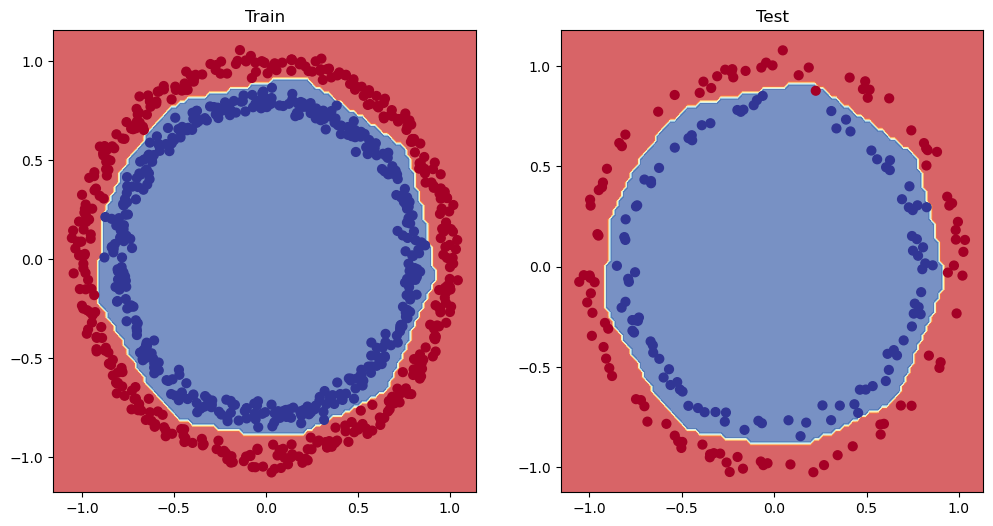

In [29]:
from helper_functions import plot_predictions, plot_decision_boundary
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test) # model_3 = has non-linearity